## Group No 16

## Group Member Names:
1. ANUP JINDAL <2023AC05472> 100%
2. YOGESH CHATURVEDI <2023ac05167 > 100%
3. HRISHIKESH MALAKAR <2023ac05058> 100%
4. NAIR ANIT KAVALIBALAN <2023ac05503> 100%

# 1. Import the required libraries

In [22]:
##---------Type the code below this line------------------##
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from tensorflow import keras
from keras import layers
from keras import Sequential
import os
import matplotlib.image as mpimg
from PIL import Image



# 2. Data Acquisition  -- Score: 0.5 Mark
 
For the problem identified by you, students have to find the data source themselves from any data source.

## 2.1 Code for converting the above downloaded data into a form suitable for DL



In [ ]:
### Code to remove corrupted images
num_skipped = 0
for folder_name in ("Cat", "Dog"):
    folder_path = os.path.join("PetImages", folder_name)
    for fname in os.listdir(folder_path):
        fpath = os.path.join(folder_path, fname)
        try:
            fobj = open(fpath, "rb")
            is_jfif = b"JFIF" in fobj.peek(10)
        finally:
            fobj.close()

        if not is_jfif:
            num_skipped += 1
            # Delete corrupted image
            os.remove(fpath)

print(f"Deleted {num_skipped} images.")

Deleted 168 images.


In [35]:
##---------Type the code below this line------------------##

### used kaggle cats and dogs data set https://www.microsoft.com/en-us/download/details.aspx?id=54765

# Load data into trainig and test

image_size = (180, 180)
batch_size = 128

# Function to convert images to RGB format
def convert_images_to_rgb(directory):
    for subdir, _, files in os.walk(directory):
        for file in files:
            file_path = os.path.join(subdir, file)
            try:
                with Image.open(file_path) as img:
                    if img.mode != 'RGB':
                        img = img.convert('RGB')
                        img.save(file_path)
            except Exception as e:
                print(f"Error processing {file_path}: {e}")
# Convert images in the PetImages directory to RGB format
convert_images_to_rgb("PetImages")




Found 23425 files belonging to 2 classes.
Using 18740 files for training.
Using 4685 files for validation.


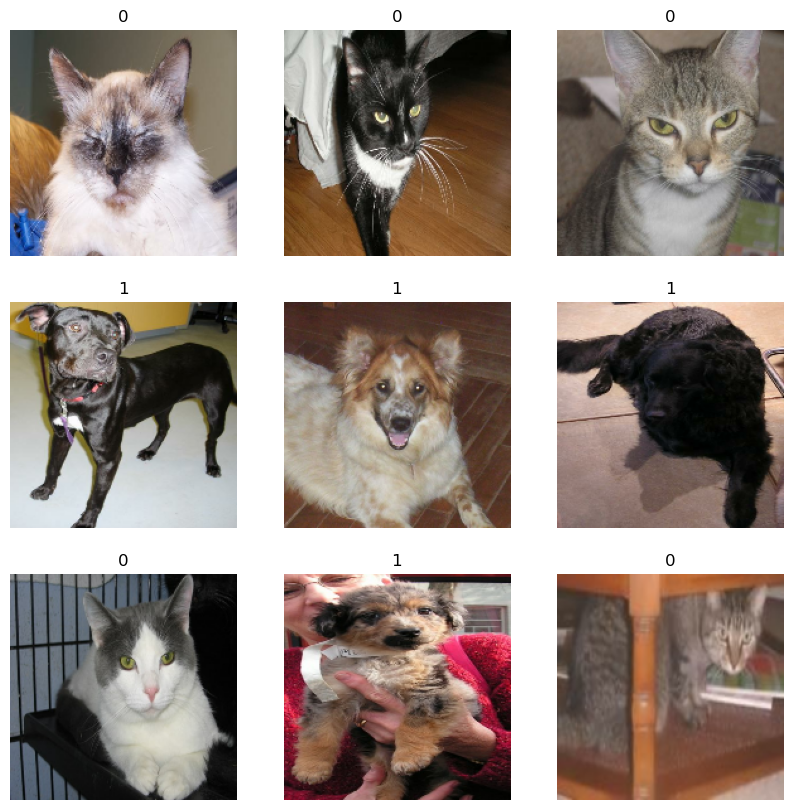

In [ ]:
# Load the dataset from the directory, splitting it into training and validation sets
train_ds, val_ds = keras.utils.image_dataset_from_directory(
    "PetImages",
    validation_split=0.2,
    subset="both",
    seed=1337,
    image_size=image_size,
    batch_size=batch_size,
)
# Display the first 9 images from the training dataset
plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(np.array(images[i]).astype("uint8"))
        plt.title(int(labels[i]))
        plt.axis("off")

## 2.1 Write your observations from the above. 

1. Size of the dataset
2. What type of data attributes are there?
3. What are you classifying?
4. Plot the distribution of the categories of the target / label. 



--------------Type the answers below this line--------------


In [37]:
# Size of data set
# 1. Size of the dataset
total_train_samples = sum([len(images) for images, _ in train_ds])
total_val_samples = sum([len(images) for images, _ in val_ds])
print(f"Total number of samples in the training dataset: {total_train_samples}")
print(f"Total number of samples in the validation dataset: {total_val_samples}")



Total number of samples in the training dataset: 18740
Total number of samples in the validation dataset: 4685


In [38]:
# 2. Type of data attributes
for images, labels in train_ds.take(1):
    print(f"Image shape: {images.shape}")
    print(f"Label shape: {labels.shape}")

Image shape: (128, 180, 180, 3)
Label shape: (128,)


In [39]:
# 3. What are you classifying?
class_names = train_ds.class_names
print(f"Classes being classified: {class_names}")

Classes being classified: ['Cat', 'Dog']


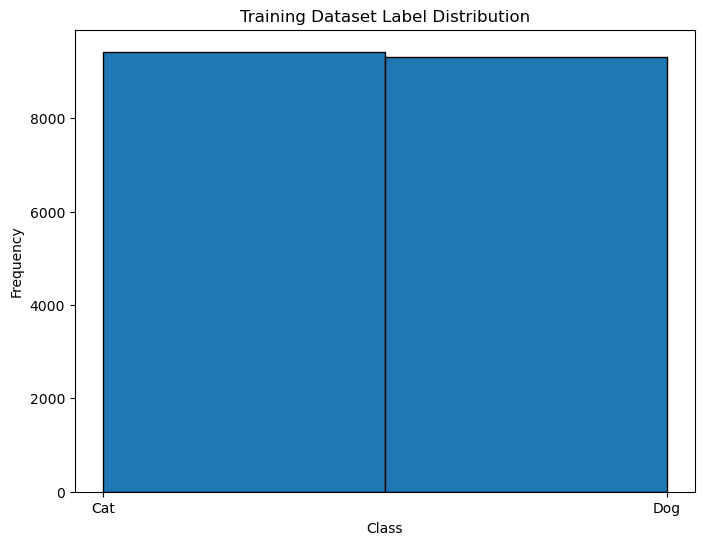

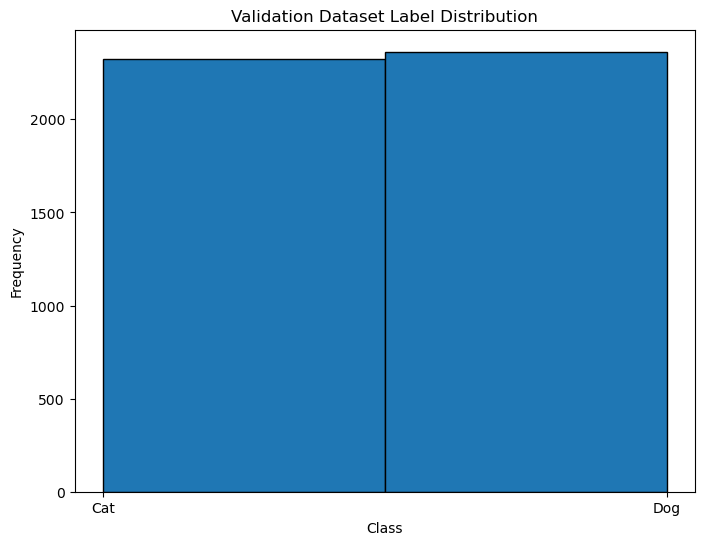

In [40]:

# 4. Plot the distribution of the categories of the target/label
def plot_label_distribution(dataset, title):
    labels = []
    for _, label_batch in dataset:
        labels.extend(label_batch.numpy())
    labels = np.array(labels)
    
    plt.figure(figsize=(8, 6))
    plt.hist(labels, bins=len(class_names), edgecolor='black')
    plt.xticks(range(len(class_names)), class_names)
    plt.xlabel('Class')
    plt.ylabel('Frequency')
    plt.title(title)
    plt.show()

plot_label_distribution(train_ds, "Training Dataset Label Distribution")
plot_label_distribution(val_ds, "Validation Dataset Label Distribution")

# 3. Data Preparation -- Score: 1 Mark

Perform the data prepracessing that is required for the data that you have downloaded. 


This stage depends on the dataset that is used. 

## 3.1 Apply pre-processing techiniques

* to remove duplicate data
* to impute or remove missing data
* to remove data inconsistencies
* Encode categorical data
* Normalize the data
* Feature Engineering
* Stop word removal, lemmatiation, stemming, vectorization


IF ANY

In [ ]:
##---------Type the code below this line------------------##

## 3.2 Identify the target variables.

* Separate the data front the target such that the dataset is in the form of (X,y) or (Features, Label)

* Discretize / Encode the target variable or perform one-hot encoding on the target or any other as and if required.





In [ ]:
##---------Type the code below this line------------------##

## 3.3 Split the data into training set and testing set

In [ ]:
##---------Type the code below this line------------------##

## 3.4 Preprocessing report

Mention the method adopted  and justify why the method was used
* to remove duplicate data, if present 
* to impute or remove missing data, if present 
* to remove data inconsistencies, if present 
* to encode categorical data 
* the normalization technique used

If the any of the above are not present, then also add in the report below.

Report the size of the training dataset and testing dataset


In [ ]:
##---------Type the answer below this line------------------##

# 4. Deep Neural Network Architecture - Score:  Marks


## 4.1 Design the architecture that you will be using

* Sequential Model Building with Activation for each layer.
* Add dense layers, specifying the number of units in each layer and the activation function used in the layer.
* Use Relu Activation function in each hidden layer
* Use Sigmoid / softmax Activation function in the output layer as required

DO NOT USE CNN OR RNN. 

In [ ]:
##---------Type the code below this line------------------##

## 4.2 DNN Report

Report the following and provide justification for the same.



* Number of layers
* Number of units in each layer
* Total number of trainable parameters 



In [ ]:
##---------Type the answer below this line------------------##

# 5. Training the model - Score: 1 Mark


## 5.1 Configure the training

Configure  the model for training, by using appropriate optimizers and regularizations

Compile with categorical CE loss and metric accuracy.

In [ ]:
##---------Type the code below this line------------------##

## 5.2 Train the model

Train Model with cross validation, with total time taken shown for 20 epochs.

Use SGD.

In [ ]:
##---------Type the code below this line------------------##

Justify your choice of optimizers and regulizations used and the hyperparameters tuned


In [ ]:
##---------Type the answers below this line------------------##

# 6. Test the model - 0.5 marks


In [ ]:
##---------Type the code below this line------------------##

# 7. Intermediate result  - Score: 1 mark

1. Plot the training and validation accuracy history.
2. Plot the training and validation loss history. 
3. Report the testing accuracy and loss.
4. Show Confusion Matrix for testing dataset.
5. Report values for preformance study metrics like accuracy, precision, recall, F1 Score.


In [ ]:
##---------Type the code below this line------------------##

# 8. Model architecture - Score: 1 mark


Modify the architecture designed in section 4.1 

1. by decreasing one layer
2. by increasing one layer

For example, if the architecture in 4.1 has 5 layers, then 8.1 should have 4 layers and 8.2 should have 6 layers.

Plot the comparison of the training and validation accuracy of the three architecures (4.1, 8.1 and 8.2)



In [ ]:
##---------Type the code below this line------------------##

# 9. Regularisations - Score: 1 mark

Modify the architecture designed in section 4.1

1. Dropout of ratio 0.25
2. Dropout of ratio 0.25 with L2 regulariser with factor 1e−04. 

Plot the comparison of the training and validation accuracy of the three (4.1, 9.1 and 9.2)



In [ ]:
##---------Type the code below this line------------------##

# 10. Optimisers -Score: 1 mark

Modify the code written in section 5.2

1. RMSProp with your choice of hyper parameters
2. Adam with your choice of hyper parameters

Plot the comparison of the training and validation accuracy of the three (5.2, 10.1 and 10.2)


In [ ]:
##---------Type the code below this line------------------##

# 11. Conclusion - Score: 1 mark

Comparing the sections 4.1, 5.2, 8, 9, and 10, present your observations on which model or architecture or regualiser or optimiser perfomed better.


In [ ]:
##---------Type the code below this line------------------##

### NOTE


All Late Submissions will incur a <b>penalty of -2 marks </b>. So submit your assignments on time.

Good Luck